In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt

c:\Users\Omar Ben Emad\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.8) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


# RNN Model

In [2]:
dataset = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = dataset.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0


In [4]:
model = keras.Sequential()
model.add(keras.Input(shape=(28, 28)))
model.add(layers.SimpleRNN(128,return_sequences=True, activation="relu"))
model.add(layers.SimpleRNN(64,return_sequences=False, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))
print(model.summary())



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 28, 128)        │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,098 (129.29 KB)

 Trainable params: 33,098 (129.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
loss = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
optimizer = keras.optimizers.Adam(learning_rate=0.001)
metrics = ["accuracy"]
model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
history = model.fit(
    train_images, train_labels, epochs=20, batch_size=32, validation_split=0.2

)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8573 - loss: 0.4455 - val_accuracy: 0.9442 - val_loss: 0.1955
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9497 - loss: 0.1770 - val_accuracy: 0.9528 - val_loss: 0.1692
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9583 - loss: 0.1458 - val_accuracy: 0.9687 - val_loss: 0.1130
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9661 - loss: 0.1201 - val_accuracy: 0.9655 - val_loss: 0.1212
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9669 - loss: 0.1122 - val_accuracy: 0.9684 - val_loss: 0.1101
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9710 - loss: 0.1025 - val_accuracy: 0.9718 - val_loss: 0.1006
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9717 - loss: 0.0996 - val_accuracy: 0.9597 - val_loss: 0.1425
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9739 - loss: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9749 - loss: 0.1006
Test Loss: 0.1006, Test Accuracy: 0.9749
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 7, Actual: 7
Predicted: 2, Actual: 2
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 4, Actual: 4
Predicted: 1, Actual: 1
Predicted: 4, Actual: 4
Predicted: 9, Actual: 9
Predicted: 5, Actual: 5
Predicted: 9, Actual: 9
Predicted: 0, Actual: 0
Predicted: 6, Actual: 6
Predicted: 9, Actual: 9
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 5, Actual: 5
Predicted: 9, Actual: 9
Predicted: 7, Actual: 7


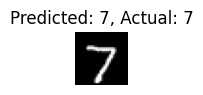

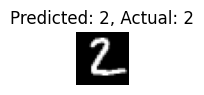

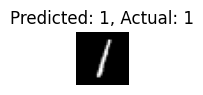

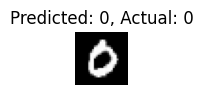

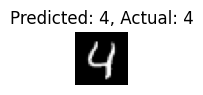

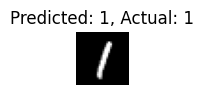

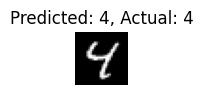

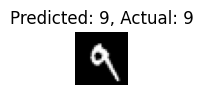

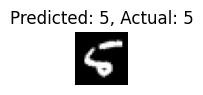

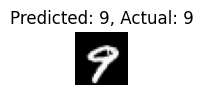

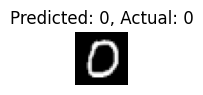

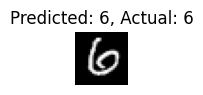

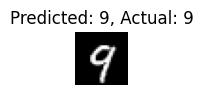

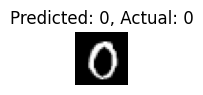

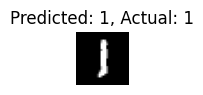

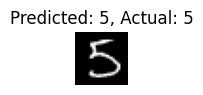

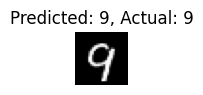

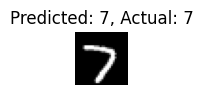

In [9]:
import numpy as np
eval = model.evaluate(test_images, test_labels, verbose=1)
print(f"Test Loss: {eval[0]:.4f}, Test Accuracy: {eval[1]:.4f}")

pred = model.predict(test_images)
for i in range(18):
    print(f"Predicted: {np.argmax(pred[i])}, Actual: {test_labels[i]}")

for i in range(18):
    plt.subplot(6, 3, i + 1)
    plt.imshow(test_images[i], cmap="gray")
    plt.grid(True)
    plt.title(f"Predicted: {np.argmax(pred[i])}, Actual: {test_labels[i]}")
    plt.axis("off")
    plt.show()

# Text Classification

In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import re
import string

In [12]:
df = pd.read_csv(r"F:\Omar 3amora\حنكشة projects\Tensforflow Practice\train_tweet.csv")
print(df.head())

   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation


In [20]:
def remove_url(text):
    url_pattern = re.compile(r"https?://\S+|www\.\S+")
    return url_pattern.sub(r"", text)
def remove_html(text):
    html_pattern = re.compile(r"<.*?>")
    return html_pattern.sub(r"", text)
def remove_punctuation(text):
    translator = str.maketrans("", "", string.punctuation)
    return text.translate(translator)

def preprocess_text(text):
    text = remove_url(text)
    text = remove_html(text)
    text = remove_punctuation(text)
    return text
df["clean_tweet"] = df["tweet"].apply(preprocess_text)
df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,user when a father is dysfunctional and is so...
1,2,0,@user @user thanks for #lyft credit i can't us...,user user thanks for lyft credit i cant use ca...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,model i love u take with u all the time in u...
4,5,0,factsguide: society now #motivation,factsguide society now motivation


In [21]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 1.9 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.2 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop = set(stopwords.words("english"))

def remove_stopwords(text):
    filtered_words = [word.lower() for word in text.split() not in stop]
    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to C:\Users\Omar Ben
[nltk_data]     Emad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
df["clean_tweet"] = df["clean_tweet"].apply(preprocess_text)


In [34]:
from collections import Counter
count = Counter()
column = df.clean_tweet
for text in column.values:
    for word in text.split():
        count[word] +=1

print(len(count))

47517


# Data split

In [36]:
train_size = int(df.shape[0]*0.8)
train_df = df[:train_size]
val_df = df[train_size:]

train_sentences = train_df.clean_tweet.to_numpy()
train_labels = train_df.label.to_numpy()
val_sentences = val_df.clean_tweet.to_numpy()
val_labels = val_df.label.to_numpy()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
# vectorize a text corpus by turning each text into a sequence of integers
tokenizer = Tokenizer(num_words=len(count))
tokenizer.fit_on_texts(train_sentences) # fit only to training
word_index = tokenizer.word_index


In [41]:
train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences = tokenizer.texts_to_sequences(val_sentences)

In [43]:
# Pad the sequences to have the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Max number of words in a sequence
max_length = 20

train_padded = pad_sequences(train_sequences, maxlen=max_length, padding="post", truncating="post")
val_padded = pad_sequences(val_sequences, maxlen=max_length, padding="post", truncating="post")
train_padded.shape, val_padded.shape

reverse_word_index = dict([(idx, word) for (word, idx) in word_index.items()])

In [44]:
def decode(sequence):
    return " ".join([reverse_word_index.get(idx, "?") for idx in sequence])
decoded_text = decode(train_sequences[10])

print(train_sequences[10])
print(decoded_text)

[166, 1184, 3058, 1538, 2026, 386, 8875, 45, 1098, 3059, 3, 3682, 8, 249, 132, 169, 160, 190]
â ireland consumer price index mom climbed from previous 02 to 05 in may blog silver gold forex


In [47]:
# Create LSTM model
from keras import layers

model = keras.models.Sequential()
model.add(layers.Embedding(len(count), 32, input_length=max_length))
model.add(layers.LSTM(64, dropout=0.1))
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()
loss = keras.losses.BinaryCrossentropy(from_logits=False)
optim = keras.optimizers.Adam(learning_rate=0.001)
metrics = ["accuracy"]

model.compile(loss=loss, optimizer=optim, metrics=metrics)
model.fit(train_padded, train_labels, epochs=20, validation_data=(val_padded, val_labels), verbose=2)
predictions = model.predict(train_padded)
predictions = [1 if p > 0.5 else 0 for p in predictions]
print(train_sentences[10:20])

print(train_labels[10:20])
print(predictions[10:20])

c:\Users\Omar Ben Emad\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
800/800 - 14s - 18ms/step - accuracy: 0.9456 - loss: 0.1758 - val_accuracy: 0.9614 - val_loss: 0.1178
Epoch 2/20
800/800 - 12s - 15ms/step - accuracy: 0.9772 - loss: 0.0720 - val_accuracy: 0.9629 - val_loss: 0.1158
Epoch 3/20
800/800 - 13s - 17ms/step - accuracy: 0.9891 - loss: 0.0366 - val_accuracy: 0.9628 - val_loss: 0.1264
Epoch 4/20
800/800 - 14s - 17ms/step - accuracy: 0.9941 - loss: 0.0212 - val_accuracy: 0.9612 - val_loss: 0.1792
Epoch 5/20
800/800 - 13s - 16ms/step - accuracy: 0.9966 - loss: 0.0133 - val_accuracy: 0.9640 - val_loss: 0.2164
Epoch 6/20
800/800 - 13s - 17ms/step - accuracy: 0.9970 - loss: 0.0096 - val_accuracy: 0.9620 - val_loss: 0.1730
Epoch 7/20
800/800 - 13s - 16ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9606 - val_loss: 0.2079
Epoch 8/20
800/800 - 13s - 16ms/step - accuracy: 0.9983 - loss: 0.0070 - val_accuracy: 0.9548 - val_loss: 0.2569
Epoch 9/20
800/800 - 13s - 16ms/step - accuracy: 0.9986 - loss: 0.0051 - val_accuracy: 0.9615 - 